# Adaptive Homogeneity: Demonstration for Discussion

**Key Claim**: The effective homogeneity degree $k_{eff}$ provides a universal, learnable representation of Morse-type potentials.

This notebook demonstrates:
1. The theoretical collapse to universal coordinates
2. A simple ML model that learns the universal curve
3. Generalization to unseen parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

---
## Part 1: The Theory

### Euler's Theorem for Homogeneous Functions
If $V(sr) = s^d V(r)$, then: $\quad r \cdot V'(r) = d \cdot V(r)$

This means **Force and Energy are linearly related** (slope = d).

### The Problem: Morse is NOT Homogeneous
$V(r) = D_e(1 - e^{-a(r-r_e)})^2$ has no constant $d$.

### The Solution: Adaptive (Position-Dependent) Homogeneity
Define: $\quad k_{eff}(r) = \frac{r \cdot V'(r)}{V(r)}$

**Key Result**: In reduced coordinates ($\rho = r/r_e$, $\alpha = a \cdot r_e$):

$$k_{eff}(\rho; \alpha) = \frac{2\alpha \rho \, e^{-\alpha(\rho-1)}}{1 - e^{-\alpha(\rho-1)}}$$

**This depends ONLY on $\rho$ and $\alpha$, NOT on $D_e$!**

In [2]:
# Core functions
def morse_V(r, De, a, re):
    return De * (1 - np.exp(-a * (r - re)))**2

def morse_dV(r, De, a, re):
    u = np.exp(-a * (r - re))
    return 2 * De * a * (1 - u) * u

def k_eff_reduced(rho, alpha):
    """k_eff in reduced coordinates. Has pole at rho=1."""
    u = np.exp(-alpha * (rho - 1))
    with np.errstate(divide='ignore', invalid='ignore'):
        k = 2 * alpha * rho * u / (1 - u)
        k[np.abs(rho - 1) < 1e-10] = np.nan
    return k

def g_regularized(rho, alpha):
    """g(rho) = (rho-1) * k_eff. Smooth everywhere, g(1) = 2."""
    u = np.exp(-alpha * (rho - 1))
    with np.errstate(divide='ignore', invalid='ignore'):
        g = 2 * alpha * rho * (rho - 1) * u / (1 - u)
        # Analytical limit at rho=1
        g[np.abs(rho - 1) < 1e-8] = 2.0
    return g

---
## Part 2: Demonstrating the Collapse

Generate 30 random Morse potentials with **different** $(D_e, r_e, a)$ but **same** stiffness $\alpha = a \cdot r_e$.

**Prediction**: Their $k_{eff}$ vs $\rho$ curves should perfectly overlap.

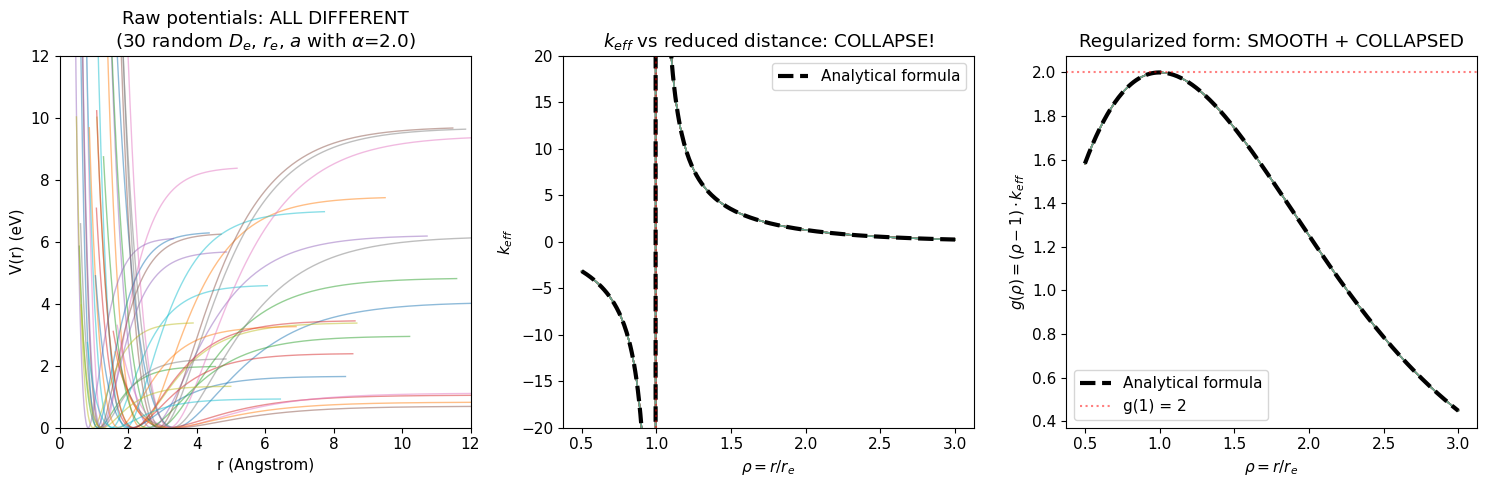

KEY INSIGHT: 30 different potentials collapse to ONE universal curve!

Dimensionality reduction: V(r; De, a, re) -> g(rho; alpha)
  - Original: 3 free parameters + position
  - Reduced: 1 free parameter (alpha) + reduced position (rho)

De COMPLETELY SCALES OUT - it only affects the overall magnitude,
not the shape of the k_eff curve!


In [3]:
np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

alpha_test = 2.0  # Fixed stiffness
n_potentials = 30

# Generate random potentials with same alpha
potentials = []
for _ in range(n_potentials):
    De = np.random.uniform(0.5, 10.0)  # eV
    re = np.random.uniform(0.7, 3.5)   # Angstrom
    a = alpha_test / re                 # Constrain so alpha = a*re = 2.0
    potentials.append((De, re, a))

# Panel 1: Raw V(r) curves - all different
ax = axes[0]
for De, re, a in potentials:
    r = np.linspace(0.5*re, 4*re, 200)
    V = morse_V(r, De, a, re)
    ax.plot(r, V, alpha=0.5, linewidth=1)
ax.set_xlabel('r (Angstrom)')
ax.set_ylabel('V(r) (eV)')
ax.set_title(f'Raw potentials: ALL DIFFERENT\n(30 random $D_e$, $r_e$, $a$ with $\\alpha$={alpha_test})')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)

# Panel 2: k_eff vs rho - should collapse!
ax = axes[1]
rho = np.linspace(0.5, 3.0, 300)
for De, re, a in potentials:
    r = rho * re
    V = morse_V(r, De, a, re)
    dV = morse_dV(r, De, a, re)
    with np.errstate(divide='ignore', invalid='ignore'):
        k = r * dV / V
        k[np.abs(V) < 1e-10] = np.nan
    ax.plot(rho, k, alpha=0.5, linewidth=1)

# Overlay the analytical formula
k_theory = k_eff_reduced(rho, alpha_test)
ax.plot(rho, k_theory, 'k--', linewidth=3, label='Analytical formula')

ax.set_xlabel('$\\rho = r/r_e$')
ax.set_ylabel('$k_{eff}$')
ax.set_title('$k_{eff}$ vs reduced distance: COLLAPSE!')
ax.set_ylim(-20, 20)
ax.axvline(1, color='r', linestyle=':', alpha=0.5)
ax.legend()

# Panel 3: Regularized g(rho) - smooth and collapsed
ax = axes[2]
for De, re, a in potentials:
    r = rho * re
    V = morse_V(r, De, a, re)
    dV = morse_dV(r, De, a, re)
    with np.errstate(divide='ignore', invalid='ignore'):
        k = r * dV / V
        g = (rho - 1) * k
        g[np.abs(rho - 1) < 1e-8] = 2.0
    ax.plot(rho, g, alpha=0.5, linewidth=1)

# Overlay analytical
g_theory = g_regularized(rho, alpha_test)
ax.plot(rho, g_theory, 'k--', linewidth=3, label='Analytical formula')

ax.set_xlabel('$\\rho = r/r_e$')
ax.set_ylabel('$g(\\rho) = (\\rho-1) \\cdot k_{eff}$')
ax.set_title('Regularized form: SMOOTH + COLLAPSED')
ax.axhline(2, color='r', linestyle=':', alpha=0.5, label='g(1) = 2')
ax.legend()

plt.tight_layout()
plt.savefig('fig1_collapse_demonstration.png', dpi=150, bbox_inches='tight')
plt.show()

print("KEY INSIGHT: 30 different potentials collapse to ONE universal curve!")
print("")
print("Dimensionality reduction: V(r; De, a, re) -> g(rho; alpha)")
print("  - Original: 3 free parameters + position")
print("  - Reduced: 1 free parameter (alpha) + reduced position (rho)")
print("")
print("De COMPLETELY SCALES OUT - it only affects the overall magnitude,")
print("not the shape of the k_eff curve!")

---
## Part 3: Machine Learning the Universal Curve

**Training**: Learn $g(\rho; \alpha)$ from data at several $\alpha$ values.

**Test**: Predict for a **new, unseen** $\alpha$ value.

In [4]:
# Generate training data
def generate_training_data(alphas, n_rho=100):
    """Generate (rho, alpha) -> g data for training."""
    X, y = [], []
    rho_grid = np.linspace(0.5, 3.0, n_rho)
    
    for alpha in alphas:
        g_values = g_regularized(rho_grid, alpha)
        for rho, g in zip(rho_grid, g_values):
            if not np.isnan(g):
                X.append([rho, alpha])
                y.append(g)
    
    return np.array(X), np.array(y)

# Training alphas: sample the range but HOLD OUT alpha=1.8 for testing
train_alphas = [0.5, 1.0, 1.2, 1.5, 2.0, 2.3, 2.5, 3.0]
test_alpha = 1.8  # Unseen during training!

X_train, y_train = generate_training_data(train_alphas, n_rho=150)

print(f"Training data: {len(X_train)} points")
print(f"Training alphas: {train_alphas}")
print(f"Test alpha (HELD OUT): {test_alpha}")

Training data: 1200 points
Training alphas: [0.5, 1.0, 1.2, 1.5, 2.0, 2.3, 2.5, 3.0]
Test alpha (HELD OUT): 1.8


In [5]:
# Train a simple neural network
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_train)
y_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

model = MLPRegressor(
    hidden_layer_sizes=(64, 64, 32),
    activation='tanh',
    max_iter=2000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

model.fit(X_scaled, y_scaled)

# Training performance
y_pred_train = scaler_y.inverse_transform(model.predict(X_scaled).reshape(-1, 1)).ravel()
train_rmse = np.sqrt(np.mean((y_train - y_pred_train)**2))
print(f"Training RMSE: {train_rmse:.6f}")

Training RMSE: 0.031426


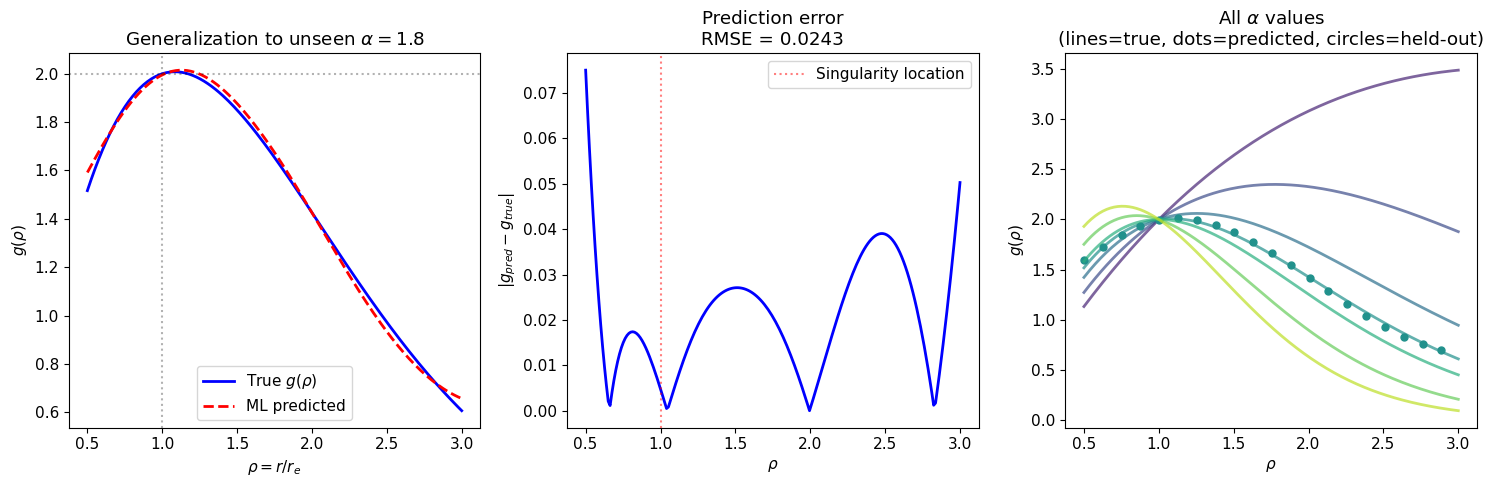


Test RMSE for held-out alpha=1.8: 0.024339
Max error: 0.075051

The ML model generalizes well to unseen stiffness values!


In [6]:
# Test on held-out alpha
rho_test = np.linspace(0.5, 3.0, 200)
X_test = np.column_stack([rho_test, np.full_like(rho_test, test_alpha)])
X_test_scaled = scaler_X.transform(X_test)

g_pred = scaler_y.inverse_transform(model.predict(X_test_scaled).reshape(-1, 1)).ravel()
g_true = g_regularized(rho_test, test_alpha)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: g(rho) comparison
ax = axes[0]
ax.plot(rho_test, g_true, 'b-', linewidth=2, label='True $g(\\rho)$')
ax.plot(rho_test, g_pred, 'r--', linewidth=2, label='ML predicted')
ax.set_xlabel('$\\rho = r/r_e$')
ax.set_ylabel('$g(\\rho)$')
ax.set_title(f'Generalization to unseen $\\alpha = {test_alpha}$')
ax.legend()
ax.axhline(2, color='k', linestyle=':', alpha=0.3)
ax.axvline(1, color='k', linestyle=':', alpha=0.3)

# Panel 2: Error
ax = axes[1]
error = np.abs(g_pred - g_true)
ax.plot(rho_test, error, 'b-', linewidth=2)
ax.set_xlabel('$\\rho$')
ax.set_ylabel('$|g_{pred} - g_{true}|$')
ax.set_title(f'Prediction error\nRMSE = {np.sqrt(np.mean(error**2)):.4f}')
ax.axvline(1, color='r', linestyle=':', alpha=0.5, label='Singularity location')
ax.legend()

# Panel 3: Compare predictions across all alphas
ax = axes[2]
all_alphas = [0.5, 1.0, 1.5, test_alpha, 2.0, 2.5, 3.0]
colors = cm.viridis(np.linspace(0.1, 0.9, len(all_alphas)))

for alpha, color in zip(all_alphas, colors):
    # True
    g_true_a = g_regularized(rho_test, alpha)
    ax.plot(rho_test, g_true_a, '-', color=color, linewidth=2, alpha=0.7)
    
    # Predicted
    X_a = np.column_stack([rho_test, np.full_like(rho_test, alpha)])
    g_pred_a = scaler_y.inverse_transform(model.predict(scaler_X.transform(X_a)).reshape(-1, 1)).ravel()
    marker = 'o' if alpha == test_alpha else ''
    ax.plot(rho_test[::10], g_pred_a[::10], marker, color=color, markersize=5, linestyle='none')

ax.set_xlabel('$\\rho$')
ax.set_ylabel('$g(\\rho)$')
ax.set_title('All $\\alpha$ values\n(lines=true, dots=predicted, circles=held-out)')

plt.tight_layout()
plt.savefig('fig2_ml_generalization.png', dpi=150, bbox_inches='tight')
plt.show()

test_rmse = np.sqrt(np.mean(error**2))
print(f"\nTest RMSE for held-out alpha={test_alpha}: {test_rmse:.6f}")
print(f"Max error: {np.max(error):.6f}")
print("\nThe ML model generalizes well to unseen stiffness values!")

---
## Part 4: The Virial Plot - Visualizing the Core Insight

For a homogeneous potential: $r \cdot F = -d \cdot V$ (a straight line!)

For Morse: this becomes a curve, and the **slope at each point** is $-k_{eff}$.

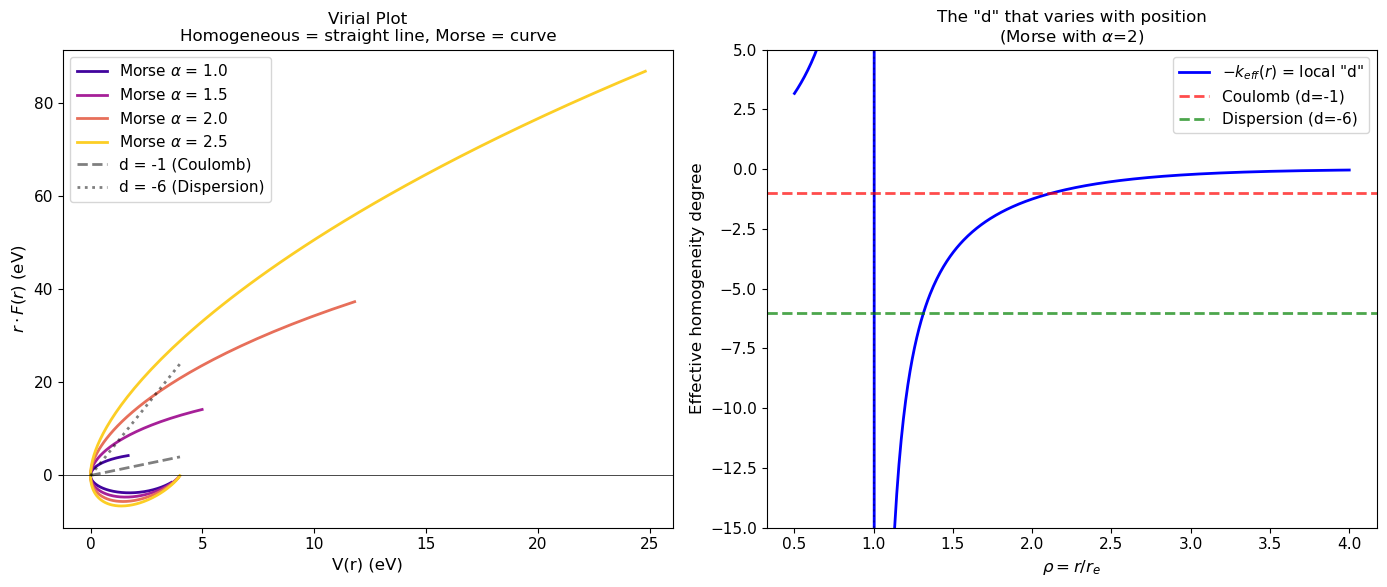

The virial plot shows WHY we need adaptive homogeneity:
  - Homogeneous potentials (Coulomb, Dispersion) give STRAIGHT LINES
  - Morse gives a CURVE
  - k_eff(r) captures the local slope at each point


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

De, re = 4.0, 1.5
r = np.linspace(0.5*re, 4*re, 500)

# Left: Virial plot for different stiffness values
ax = axes[0]
alphas = [1.0, 1.5, 2.0, 2.5]
colors = cm.plasma(np.linspace(0.1, 0.9, len(alphas)))

for alpha, color in zip(alphas, colors):
    a = alpha / re
    V = morse_V(r, De, a, re)
    dV = morse_dV(r, De, a, re)
    F = -dV
    virial = r * F
    ax.plot(V, virial, color=color, linewidth=2, label=f'Morse $\\alpha$ = {alpha}')

# Reference lines for constant homogeneity
V_line = np.linspace(0, De, 100)
ax.plot(V_line, 1 * V_line, 'k--', alpha=0.5, linewidth=2, label='d = -1 (Coulomb)')
ax.plot(V_line, 6 * V_line, 'k:', alpha=0.5, linewidth=2, label='d = -6 (Dispersion)')

ax.set_xlabel('V(r) (eV)', fontsize=12)
ax.set_ylabel('$r \\cdot F(r)$ (eV)', fontsize=12)
ax.set_title('Virial Plot\nHomogeneous = straight line, Morse = curve', fontsize=12)
ax.legend()
ax.axhline(0, color='k', linewidth=0.5)

# Right: k_eff as the local slope
ax = axes[1]
alpha = 2.0
a = alpha / re
V = morse_V(r, De, a, re)
dV = morse_dV(r, De, a, re)

with np.errstate(divide='ignore', invalid='ignore'):
    k = r * dV / V
    k[np.abs(V) < 1e-10] = np.nan

ax.plot(r/re, -k, 'b-', linewidth=2, label='$-k_{eff}(r)$ = local "d"')
ax.axhline(-1, color='r', linestyle='--', alpha=0.7, linewidth=2, label='Coulomb (d=-1)')
ax.axhline(-6, color='g', linestyle='--', alpha=0.7, linewidth=2, label='Dispersion (d=-6)')
ax.axvline(1, color='k', linestyle=':', alpha=0.3)
ax.set_xlabel('$\\rho = r/r_e$', fontsize=12)
ax.set_ylabel('Effective homogeneity degree', fontsize=12)
ax.set_title('The "d" that varies with position\n(Morse with $\\alpha$=2)', fontsize=12)
ax.set_ylim(-15, 5)
ax.legend()

plt.tight_layout()
plt.savefig('fig3_virial_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("The virial plot shows WHY we need adaptive homogeneity:")
print("  - Homogeneous potentials (Coulomb, Dispersion) give STRAIGHT LINES")
print("  - Morse gives a CURVE")
print("  - k_eff(r) captures the local slope at each point")

---
## Part 5: Summary for Discussion with Anatole

In [8]:
print("="*70)
print("EXECUTIVE SUMMARY: Adaptive Homogeneity for ML Potentials")
print("="*70)
print("")
print("THE IDEA (from the chalkboard):")
print("-" * 50)
print("For homogeneous functions: x . grad(f) = d . f")
print("This makes Force <-> Energy LINEAR (easy for ML!)")
print("")
print("Problem: Morse potential is NOT homogeneous.")
print("Solution: Make 'd' position-dependent: k_eff(r) = r.V'/V")
print("")
print("="*70)
print("")
print("KEY RESULTS:")
print("-" * 50)
print("")
print("1. UNIVERSAL COLLAPSE (Figure 1)")
print("   - 30 different Morse potentials collapse to ONE curve")
print("   - k_eff depends only on (rho, alpha), NOT on De")
print("   - Dimensionality: 3 params -> 1 param")
print("")
print("2. ANALYTICAL FORMULA DERIVED")
print("   k_eff(rho; alpha) = 2*alpha*rho*exp(-alpha(rho-1)) / (1 - exp(-alpha(rho-1)))")
print("   ")
print("   Singularity at rho=1: k_eff ~ 2/(rho-1) + 2 (simple pole, residue=2)")
print("   Regularization: g(rho) = (rho-1)*k_eff is SMOOTH, g(1) = 2")
print("")
print("3. ML GENERALIZATION (Figure 2)")
print(f"   - Trained on 8 alpha values")
print(f"   - Tested on held-out alpha = {test_alpha}")
print(f"   - Test RMSE: {test_rmse:.4f}")
print("   - Smooth interpolation in alpha space")
print("")
print("="*70)
print("")
print("THE ML SETUP:")
print("-" * 50)
print("  Input:  (rho, alpha) where rho=r/re, alpha=a.re")
print("  Target: g(rho) = (rho-1).k_eff  [smooth, no singularity]")
print("  ")
print("  To get V(r): need De (from boundary condition) + integration")
print("  OR: learn De separately and use V = De * f(rho, alpha)")
print("")
print("="*70)
print("")
print("OPEN QUESTIONS FOR DISCUSSION:")
print("-" * 50)
print("1. Singularity handling: pole subtraction vs regularization?")
print("2. Extension to many-body: how does alpha generalize?")
print("3. Connection to Rose equation / UBER?")
print("4. Real diatomic data: NIST, ExoMol validation?")
print("5. Beyond Morse: LJ, Buckingham, ab initio curves?")
print("6. Recovery of V(r): best numerical approach?")
print("")
print("="*70)

EXECUTIVE SUMMARY: Adaptive Homogeneity for ML Potentials

THE IDEA (from the chalkboard):
--------------------------------------------------
For homogeneous functions: x . grad(f) = d . f
This makes Force <-> Energy LINEAR (easy for ML!)

Problem: Morse potential is NOT homogeneous.
Solution: Make 'd' position-dependent: k_eff(r) = r.V'/V


KEY RESULTS:
--------------------------------------------------

1. UNIVERSAL COLLAPSE (Figure 1)
   - 30 different Morse potentials collapse to ONE curve
   - k_eff depends only on (rho, alpha), NOT on De
   - Dimensionality: 3 params -> 1 param

2. ANALYTICAL FORMULA DERIVED
   k_eff(rho; alpha) = 2*alpha*rho*exp(-alpha(rho-1)) / (1 - exp(-alpha(rho-1)))
   
   Singularity at rho=1: k_eff ~ 2/(rho-1) + 2 (simple pole, residue=2)
   Regularization: g(rho) = (rho-1)*k_eff is SMOOTH, g(1) = 2

3. ML GENERALIZATION (Figure 2)
   - Trained on 8 alpha values
   - Tested on held-out alpha = 1.8
   - Test RMSE: 0.0243
   - Smooth interpolation in alpha s